# Assoziationsanalyse: Welche Wege gehören zusammen?

**Verfahren:** Assoziationsanalyse (unüberwacht — das Ergebnis sind Regeln, keine Zahlen und keine Gruppen)  |  **Geschäftsfrage:** Zwischen welchen Stationen gibt es systematische Ströme, und wann?

[![In Colab öffnen](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/swrobuts/velocity-fallstudie/blob/main/analytics/notebooks/05_Assoziation_Wege_im_Netz.ipynb)

---

## Wie dieses Notebook aufgebaut ist

Es folgt **CRISP-DM** (*Cross-Industry Standard Process for Data Mining*) — dem
Vorgehensmodell, das seit 1999 der De-facto-Standard für Analyseprojekte ist. Sechs
Phasen, und zwar als **Kreislauf**, nicht als Treppe:

| | Phase | Leitfrage |
|---|---|---|
| 1 | Business Understanding | Was ist die Geschäftsfrage — und woran messen wir Erfolg? |
| 2 | Data Understanding | Welche Daten haben wir, und taugen sie für diese Frage? |
| 3 | Data Preparation | Wie wird aus Rohdaten eine Tabelle, mit der ein Verfahren rechnen kann? |
| 4 | Modeling | Welches Verfahren, welche Einstellungen, wie geprüft? |
| 5 | Evaluation | Ist das Modell gut genug für die Geschäftsfrage aus Phase 1? |
| 6 | Deployment | Wie kommt das Modell in den Betrieb — und was passiert danach? |

**Der Pfeil von Phase 5 zurück auf Phase 1 ist kein Schönheitsfehler des Diagramms.**
Er ist die wichtigste Linie darin. In der Praxis stellt sich in der Evaluation regelmäßig
heraus, dass die Frage aus Phase 1 anders gestellt werden muss oder dass Daten fehlen,
an die in Phase 2 niemand gedacht hat. Ein Analyseprojekt, das die sechs Phasen genau
einmal von oben nach unten durchläuft, ist die Ausnahme — nicht die Regel.

Am Ende dieses Notebooks steht deshalb ausdrücklich die Frage, **was eine zweite Runde
anders machen würde**.

## Das dritte Gesicht des maschinellen Lernens

| Notebook | Ergebnis des Verfahrens |
|---|---|
| 1 und 2 | eine **Vorhersage** je Objekt (Dauer, Ausfallrisiko) |
| 3 | eine **Gruppe** je Objekt (Stationstyp, Kundensegment) |
| **5** | **Regeln über Zusammenhänge** — keine Vorhersage, keine Gruppe |

Die Assoziationsanalyse stammt aus dem Handel und heißt dort **Warenkorbanalyse**: Welche
Artikel liegen zusammen im Einkaufswagen? Das berühmte (und wahrscheinlich erfundene)
Beispiel ist *Windeln und Bier*.

Übertragen auf VeloCity: **Eine Fahrt ist ein Warenkorb.** Darin liegen die Startstation,
die Zielstation, die Tageszeit, der Wochentag, der Radtyp. Die Frage lautet: Was liegt
regelmäßig zusammen im selben Korb?

> **Warum wir das ohne Bibliothek rechnen.** Für Assoziationsregeln gibt es fertige
> Pakete (`mlxtend`, `apyori`). Wir rechnen die drei Kennzahlen hier von Hand — sie
> bestehen aus je einer Division, und wer sie einmal selbst gerechnet hat, fällt später
> nicht auf eine Regel herein, die nur nach etwas aussieht.

---

**1. Business** · 2. Data · 3. Data · 4. Modeling · 5. Evaluation · 6. Deployment

# Phase 1 von 6 — Business Understanding

> **Leitfrage:** Was ist die Geschäftsfrage — und woran messen wir Erfolg?
>
> **In diesem Notebook heißt das:** Die Disposition weiß, dass sie morgens umverteilen muss. Sie weiß nicht, **wohin**.

### Die Ausgangslage

Aus Notebook 3 wissen wir, welche **Typen** von Stationen es gibt. Was wir nicht wissen:
**welche Station sich zugunsten welcher anderen leert.** Der Transporter fährt morgens
los und verteilt nach Gefühl um.

Die Frage ist also nicht mehr „wie viele Räder“ (das war Notebook 4), sondern
**„von wo nach wo“**.

### Warum Assoziationsanalyse und nicht einfach eine Kreuztabelle?

Eine Kreuztabelle Start × Ziel könnte man auch bauen. Sie hätte aber ein Problem: Sie
zeigt **absolute Häufigkeiten**, und die größten Zahlen stehen dort, wo einfach am
meisten los ist. Der Hauptbahnhof taucht überall oben auf — nicht weil er besondere
Beziehungen hat, sondern weil er groß ist.

Die Assoziationsanalyse rechnet das heraus. Ihre dritte Kennzahl, der **Lift**, fragt
genau das: *Kommt diese Kombination häufiger vor, als man bei Unabhängigkeit erwarten
würde?*

### Die drei Kennzahlen — an einem Beispiel aus dem Handel

Regel: **{Brot} → {Butter}**

| Kennzahl | Frage | Rechnung |
|---|---|---|
| **Support** | Wie oft kommt die Kombination überhaupt vor? | Körbe mit Brot *und* Butter ÷ alle Körbe |
| **Konfidenz** | Wenn Brot drin ist — wie oft dann auch Butter? | Körbe mit beidem ÷ Körbe mit Brot |
| **Lift** | Ist das mehr, als der Zufall hergäbe? | Konfidenz ÷ Anteil aller Körbe mit Butter |

**Lift = 1** heißt: kein Zusammenhang. **Lift = 2**: doppelt so häufig wie erwartet.
**Lift < 1**: die beiden meiden einander.

### Die Erfolgskriterien

Eine Regel ist für die Disposition **nur dann brauchbar**, wenn alle drei zutreffen:

| | Kriterium | Schwelle | Warum |
|---|---|---|---|
| 1 | **Support** | mindestens 1 % aller Fahrten | Für eine Regel, die zwanzig Fahrten im Jahr betrifft, fährt kein Transporter |
| 2 | **Lift** | mindestens 1,3 | Darunter ist es Zufall oder schlicht Größe |
| 3 | **Handlungsfähig** | die Regel muss eine Fahrt des Transporters begründen | „Käppele → Käppele“ ist wahr und nutzlos |

**Kriterium 1 ist das, das am meisten Regeln aussortiert** — und zwar gerade die mit den
spektakulärsten Lift-Werten. Wir werden das gleich sehen.

---

1. Business · **2. Data** · 3. Data · 4. Modeling · 5. Evaluation · 6. Deployment

# Phase 2 von 6 — Data Understanding

> **Leitfrage:** Welche Daten haben wir, und taugen sie für diese Frage?
>
> **In diesem Notebook heißt das:** Was liegt in unseren Warenkörben, und wie häufig ist jedes Ding für sich?

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASIS = os.environ.get("VELO_BASIS",
    "https://raw.githubusercontent.com/swrobuts/velocity-fallstudie/main/analytics/")
pd.set_option("display.width", 160)

fahrten = pd.read_csv(BASIS + "ausleihe.csv", parse_dates=["startzeit"])
stationen = pd.read_csv(BASIS + "station.csv")
raeder = pd.read_csv(BASIS + "fahrrad.csv")
feiertage = set(pd.read_csv(BASIS + "feiertage.csv").datum)

k = fahrten[fahrten.status == "abgeschlossen"].copy()
namen = stationen.set_index("station_id").name
k["start"] = k.start_station_id.map(namen)
k["ziel"] = k.end_station_id.map(namen)
k["stunde"] = k.startzeit.dt.hour
k["ist_frei"] = ((k.startzeit.dt.dayofweek >= 5)
                 | k.startzeit.dt.strftime("%Y-%m-%d").isin(feiertage))
k = k.merge(raeder[["fahrrad_id", "typ_code"]], on="fahrrad_id", how="left")

print(f"{len(k):,d} Fahrten als 'Warenkörbe'".replace(",", "."))
print("\nWie häufig ist jede Station als ZIEL? (das sind die Basisraten für den Lift)")
basis_ziel = k.ziel.value_counts(normalize=True)
print((basis_ziel * 100).round(1).to_string())

58.519 Fahrten als 'Warenkörbe'

Wie häufig ist jede Station als ZIEL? (das sind die Basisraten für den Lift)
ziel
Kaeppele              12.9
Ringpark Nord         12.8
Alte Mainbruecke      12.6
Residenz              12.6
Hauptbahnhof           9.2
Grombuehl/Klinikum     8.4
Marktplatz             8.1
Zellerau               8.1
Hubland                7.9
Sanderring             7.5


**Diese Tabelle ist wichtiger, als sie aussieht.** Sie ist der Maßstab, gegen den der
Lift rechnet. Die Zielanteile liegen alle zwischen etwa 9 und 11 % — die zehn Stationen
sind also ähnlich beliebt. Genau deshalb wird eine Konfidenz von 30 % gleich als
auffällig zu erkennen sein: Sie ist dreimal so hoch wie der Zufall hergäbe.

### 2.1 Der triviale Zusammenhang, den man zuerst finden muss

In [2]:
rundtour = (k.start == k.ziel).mean()
print(f"Anteil Rundtouren (Start = Ziel): {rundtour:.1%}")
print("\nRundtouren je Startstation:")
je_station = k.assign(ist_rundtour=(k.start == k.ziel)).groupby("start").ist_rundtour.mean()
print((je_station.sort_values(ascending=False) * 100).round(1).to_string())

Anteil Rundtouren (Start = Ziel): 20.6%

Rundtouren je Startstation:
start
Ringpark Nord         32.2
Residenz              31.4
Kaeppele              31.2
Alte Mainbruecke      29.6
Sanderring            13.1
Zellerau              13.0
Hubland               12.3
Grombuehl/Klinikum    12.3
Hauptbahnhof          11.8
Marktplatz            11.1


**Ein Fünftel aller Fahrten endet dort, wo es begann** — und bei den Ausflugsstationen
ist es ein Drittel. Das ist der stärkste „Zusammenhang“ im ganzen Datensatz, und er wird
jede Regelliste anführen, wenn man ihn nicht ausschließt.

**Nützlich ist er trotzdem nicht.** Eine Rundtour verschiebt kein einziges Rad; für die
Disposition ist sie ein Nullsummenvorgang. Wir schließen Rundtouren deshalb aus der
Regelsuche aus — **ausdrücklich und begründet**, nicht heimlich.

> Das ist ein wiederkehrendes Muster bei Assoziationsanalysen: **Die stärkste Regel ist
> fast immer die, die man schon kannte.** Im Supermarkt ist es „wer Milch kauft, kauft
> Milch derselben Marke“. Der Wert des Verfahrens beginnt erst darunter.

---

1. Business · 2. Data · **3. Data** · 4. Modeling · 5. Evaluation · 6. Deployment

# Phase 3 von 6 — Data Preparation

> **Leitfrage:** Wie wird aus Rohdaten eine Tabelle, mit der ein Verfahren rechnen kann?
>
> **In diesem Notebook heißt das:** Aus jeder Fahrt wird ein Warenkorb mit Zeitfenster und Tagesart.

In [3]:
# Zeitfenster statt Stunden: 24 Stunden ergaeben 24 mal so viele Regeln mit je
# einem Vierundzwanzigstel der Belege. Vier Fenster halten die Regeln belegbar
# und entsprechen dem, wonach die Disposition ohnehin plant.
GRENZEN = [0, 10, 15, 20, 24]
BEZEICHNUNGEN = ["früh (5-10)", "mittag (10-15)", "abend (15-20)", "spät (20-24)"]

k["fenster"] = pd.cut(k.stunde, GRENZEN, labels=BEZEICHNUNGEN, right=False)
k["tagesart"] = np.where(k.ist_frei, "frei", "Werktag")

koerbe = k[k.start != k.ziel].copy()      # Rundtouren ausgeschlossen, siehe Phase 2
print(f"Warenkörbe für die Regelsuche: {len(koerbe):,d}".replace(",", "."))
print("\nVerteilung über die Zeitfenster:")
print(pd.crosstab(koerbe.fenster, koerbe.tagesart, margins=True).to_string())

Warenkörbe für die Regelsuche: 46.491

Verteilung über die Zeitfenster:
tagesart        Werktag   frei    All
fenster                              
früh (5-10)        9211   1879  11090
mittag (10-15)    10419   4689  15108
abend (15-20)     11791   4741  16532
spät (20-24)       2554   1207   3761
All               33975  12516  46491


---

1. Business · 2. Data · 3. Data · **4. Modeling** · 5. Evaluation · 6. Deployment

# Phase 4 von 6 — Modeling

> **Leitfrage:** Welches Verfahren, welche Einstellungen, wie geprüft?
>
> **In diesem Notebook heißt das:** Support, Konfidenz und Lift — drei Divisionen, von Hand gerechnet.

In [4]:
def regeln_finden(koerbe, kontextspalten, mindest_support=0.005):
    """Findet Regeln {Start, Kontext} -> {Ziel} und rechnet die drei Kennzahlen.

    Bewusst ohne Bibliothek: jede Zeile hier entspricht einer Zeile in der
    Definition aus Phase 1.
    """
    n = len(koerbe)
    zeilen = []
    for kontext, teil in koerbe.groupby(kontextspalten, observed=True):
        if not isinstance(kontext, tuple):
            kontext = (kontext,)
        # Basisrate des Ziels IM SELBEN KONTEXT - sonst vergliche man
        # Aepfel mit Birnen (Werktagsziele gegen Wochenendziele).
        basis = teil.ziel.value_counts(normalize=True)
        n_kontext = len(teil)
        for start, gruppe in teil.groupby("start", observed=True):
            n_start = len(gruppe)
            for ziel, n_beide in gruppe.ziel.value_counts().items():
                support = n_beide / n
                if support < mindest_support:
                    continue
                konfidenz = n_beide / n_start
                lift = konfidenz / basis[ziel]
                zeilen.append({
                    "Kontext": " · ".join(map(str, kontext)),
                    "wenn Start": start, "dann Ziel": ziel,
                    "Fahrten": n_beide,
                    "Support": round(support, 4),
                    "Konfidenz": round(konfidenz, 3),
                    "Lift": round(lift, 2),
                })
    return pd.DataFrame(zeilen)

regeln = regeln_finden(koerbe, ["tagesart", "fenster"])
print(f"{len(regeln)} Regeln mit mindestens 0,5 % Support gefunden.\n")
print("Die zehn Regeln mit dem höchsten Lift:")
print(regeln.nlargest(10, "Lift").to_string(index=False))

23 Regeln mit mindestens 0,5 % Support gefunden.

Die zehn Regeln mit dem höchsten Lift:
                Kontext         wenn Start          dann Ziel  Fahrten  Support  Konfidenz  Lift
Werktag · abend (15-20)            Hubland       Hauptbahnhof      303   0.0065      0.370  2.14
  frei · mittag (10-15)   Alte Mainbruecke           Kaeppele      351   0.0075      0.413  2.08
Werktag · abend (15-20)         Sanderring       Hauptbahnhof      258   0.0055      0.328  1.89
   frei · abend (15-20)           Kaeppele   Alte Mainbruecke      327   0.0070      0.363  1.88
  frei · mittag (10-15)           Residenz      Ringpark Nord      285   0.0061      0.330  1.86
  Werktag · früh (5-10)           Zellerau         Marktplatz      474   0.0102      0.253  1.76
Werktag · abend (15-20) Grombuehl/Klinikum       Hauptbahnhof      548   0.0118      0.293  1.69
  Werktag · früh (5-10)       Hauptbahnhof            Hubland      686   0.0148      0.358  1.66
  Werktag · früh (5-10)       Hauptbah

### Die Zahlen einer einzelnen Regel nachrechnen

Damit klar ist, dass hier keine Magie stattfindet, rechnen wir eine Regel von Hand nach.

In [5]:
beispiel = regeln.nlargest(1, "Lift").iloc[0]
teil = koerbe[(koerbe.tagesart == beispiel.Kontext.split(" · ")[0])
              & (koerbe.fenster == beispiel.Kontext.split(" · ")[1])]
n_gesamt = len(koerbe)
n_start = int((teil.start == beispiel["wenn Start"]).sum())
n_beide = int(((teil.start == beispiel["wenn Start"]) & (teil.ziel == beispiel["dann Ziel"])).sum())
basisrate = (teil.ziel == beispiel["dann Ziel"]).mean()

print(f"Regel:  WENN Start = {beispiel['wenn Start']}  ({beispiel.Kontext})")
print(f"        DANN Ziel  = {beispiel['dann Ziel']}\n")
def zeile(text, zahl):
    print(f"  {text:<46s}{f'{zahl:,d}'.replace(',', '.'):>9s}")

zeile("Fahrten insgesamt (alle Kontexte)", n_gesamt)
zeile(f"Fahrten ab {beispiel['wenn Start']} in diesem Kontext", n_start)
zeile(f"davon nach {beispiel['dann Ziel']}", n_beide)
print()
print(f"  Support    = {n_beide} / {n_gesamt}   = {n_beide/n_gesamt:.4f}  ({n_beide/n_gesamt:.2%})")
print(f"  Konfidenz  = {n_beide} / {n_start}      = {n_beide/n_start:.3f}   ({n_beide/n_start:.1%})")
print(f"  Basisrate  = Anteil aller Fahrten in diesem Kontext nach "
      f"{beispiel['dann Ziel']} = {basisrate:.3f}")
print(f"  Lift       = {n_beide/n_start:.3f} / {basisrate:.3f} = {(n_beide/n_start)/basisrate:.2f}")

Regel:  WENN Start = Hubland  (Werktag · abend (15-20))
        DANN Ziel  = Hauptbahnhof

  Fahrten insgesamt (alle Kontexte)                46.491
  Fahrten ab Hubland in diesem Kontext                818
  davon nach Hauptbahnhof                             303

  Support    = 303 / 46491   = 0.0065  (0.65%)
  Konfidenz  = 303 / 818      = 0.370   (37.0%)
  Basisrate  = Anteil aller Fahrten in diesem Kontext nach Hauptbahnhof = 0.173
  Lift       = 0.370 / 0.173 = 2.14


---

1. Business · 2. Data · 3. Data · 4. Modeling · **5. Evaluation** · 6. Deployment

# Phase 5 von 6 — Evaluation

> **Leitfrage:** Ist das Modell gut genug für die Geschäftsfrage aus Phase 1?
>
> **In diesem Notebook heißt das:** Die Regeln mit dem höchsten Lift sind nicht die nützlichsten. Jetzt kommen die Kriterien aus Phase 1 zum Einsatz.

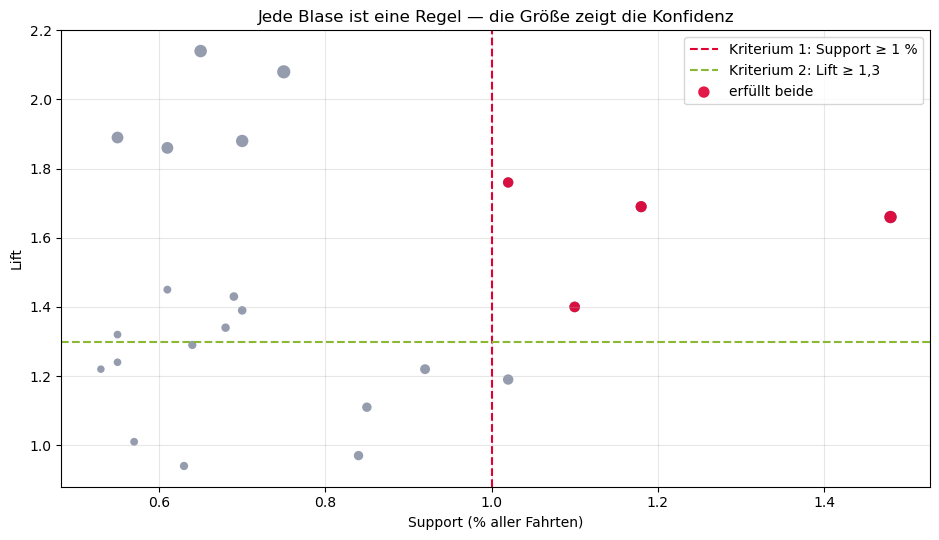

Regeln insgesamt:            23
davon mit Lift ≥ 1,3:        14
davon mit Support ≥ 1 %:     5
davon mit BEIDEM:            4


In [6]:
plt.figure(figsize=(9.5, 5.5))
plt.scatter(regeln.Support * 100, regeln.Lift, s=regeln.Konfidenz * 220,
            alpha=.55, color="#3d4b6b", edgecolor="none")
plt.axvline(1.0, color="#e00034", ls="--", label="Kriterium 1: Support ≥ 1 %")
plt.axhline(1.3, color="#8AB833", ls="--", label="Kriterium 2: Lift ≥ 1,3")
brauchbar = regeln[(regeln.Support >= 0.01) & (regeln.Lift >= 1.3)]
plt.scatter(brauchbar.Support * 100, brauchbar.Lift, s=brauchbar.Konfidenz * 220,
            alpha=.9, color="#e00034", edgecolor="none", label="erfüllt beide")
plt.xlabel("Support (% aller Fahrten)"); plt.ylabel("Lift")
plt.title("Jede Blase ist eine Regel — die Größe zeigt die Konfidenz")
plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f"Regeln insgesamt:            {len(regeln)}")
print(f"davon mit Lift ≥ 1,3:        {(regeln.Lift >= 1.3).sum()}")
print(f"davon mit Support ≥ 1 %:     {(regeln.Support >= 0.01).sum()}")
print(f"davon mit BEIDEM:            {len(brauchbar)}")

### 5.1 Das Bild erzählt die ganze Geschichte

Die Punktwolke fällt nach rechts ab, und das ist kein Zufall, sondern fast ein
Naturgesetz dieser Methode:

> **Je spezieller eine Regel, desto größer ihr Lift und desto kleiner ihr Support.**

Ganz links oben stehen die spektakulären Regeln — hoher Lift, aber ein Support von
Bruchteilen eines Prozents. Sie beschreiben eine Handvoll Fahrten. Für die Disposition
sind sie wertlos, und schlimmer noch: Bei so wenigen Fällen ist der hohe Lift oft
schlicht Zufall.

**Wer eine Regelliste nach Lift sortiert und die ersten zehn vorträgt, trägt zehn
Zufälle vor.** Das ist der häufigste Fehler bei Assoziationsanalysen.

### 5.2 Die brauchbaren Regeln

In [7]:
ergebnis = brauchbar.sort_values(["Kontext", "Lift"], ascending=[True, False])
print(ergebnis.to_string(index=False))

                Kontext         wenn Start    dann Ziel  Fahrten  Support  Konfidenz  Lift
Werktag · abend (15-20) Grombuehl/Klinikum Hauptbahnhof      548   0.0118      0.293  1.69
  Werktag · früh (5-10)           Zellerau   Marktplatz      474   0.0102      0.253  1.76
  Werktag · früh (5-10)       Hauptbahnhof      Hubland      686   0.0148      0.358  1.66
  Werktag · früh (5-10)       Hauptbahnhof   Sanderring      511   0.0110      0.267  1.40


### 5.3 Kriterium 3: Was davon begründet eine Fahrt des Transporters?

Jetzt kommt der Teil, den keine Kennzahl abnimmt. Lesen Sie die Regeln und fragen Sie bei
jeder: **Was würde die Disposition anders machen?**

Zwei Muster stechen heraus, und sie gehören zusammen:

- **morgens** fließt es von den Pendlerstationen zu den Uni-Stationen
- **abends** fließt dasselbe zurück

Das ist der klassische Pendelstrom — und für den Transporter bedeutet er: Die
Uni-Stationen laufen im Lauf des Vormittags voll und sind abends leer, die
Pendlerstationen umgekehrt. **Wer morgens um 6 Uhr am Hubland auffüllt, hat den Tag
falsch verstanden.**

> **Ein Wort zur Vorsicht.** Wir haben hier keine Ursache nachgewiesen. Wir haben
> gezeigt, dass zwei Dinge häufiger zusammen auftreten als erwartet — mehr nicht. Dass
> es dieselben Menschen sind, die morgens hin- und abends zurückfahren, ist eine
> *plausible Deutung*, keine Messung. Prüfen ließe sie sich über die `kunde_id`; das wäre
> eine eigene Analyse.

In [8]:
# Die Gegenprobe zur Deutung: fahren morgens und abends dieselben Leute?
morgens = koerbe[(koerbe.tagesart == "Werktag") & (koerbe.fenster == "früh (5-10)")
                 & (koerbe.start == "Hauptbahnhof") & (koerbe.ziel == "Hubland")]
abends = koerbe[(koerbe.tagesart == "Werktag") & (koerbe.fenster == "abend (15-20)")
                & (koerbe.start == "Hubland") & (koerbe.ziel == "Hauptbahnhof")]
gemeinsam = set(morgens.kunde_id) & set(abends.kunde_id)

print(f"Kundschaft mit Fahrt Hauptbahnhof -> Hubland  (morgens): {morgens.kunde_id.nunique():>5d}")
print(f"Kundschaft mit Fahrt Hubland -> Hauptbahnhof  (abends):  {abends.kunde_id.nunique():>5d}")
print(f"Personen, die BEIDES getan haben:                       {len(gemeinsam):>5d}")
print(f"\nAnteil an der Morgengruppe: {len(gemeinsam)/max(morgens.kunde_id.nunique(),1):.1%}")

Kundschaft mit Fahrt Hauptbahnhof -> Hubland  (morgens):   439
Kundschaft mit Fahrt Hubland -> Hauptbahnhof  (abends):    274
Personen, die BEIDES getan haben:                         104

Anteil an der Morgengruppe: 23.7%


**Die Deutung hält stand — teilweise.** Knapp ein Viertel derer, die morgens vom Bahnhof
zum Campus fahren, fährt abends dieselbe Strecke zurück. Das ist deutlich mehr, als
Zufall hergäbe, aber es sind eben auch drei Viertel, die es **nicht** tun: Sie fahren
anders zurück, zu anderer Zeit, oder gar nicht. Damit ist aus der Assoziationsregel eine belegte
Aussage über Personen geworden — und genau so geht man mit einer Regel um, die man
ernst nehmen will: **nachfassen, nicht glauben.**

---

1. Business · 2. Data · 3. Data · 4. Modeling · 5. Evaluation · **6. Deployment**

# Phase 6 von 6 — Deployment

> **Leitfrage:** Wie kommt das Modell in den Betrieb — und was passiert danach?
>
> **In diesem Notebook heißt das:** Aus Regeln wird ein Umlaufplan für den Transporter.

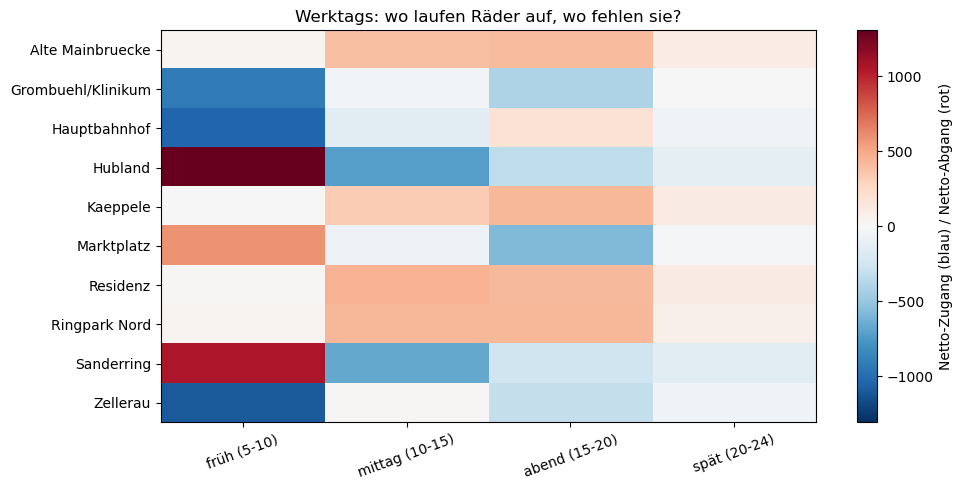

fenster             früh (5-10)  mittag (10-15)  abend (15-20)  spät (20-24)
station                                                                     
Alte Mainbruecke             37             396            413            98
Grombuehl/Klinikum         -913             -36           -403            -3
Hauptbahnhof              -1033            -136            185           -42
Hubland                    1307            -715           -336          -125
Kaeppele                      6             329            433           105
Marktplatz                  588             -72           -574           -23
Residenz                     20             459            421           107
Ringpark Nord                31             431            437            64
Sanderring                 1056            -669           -265          -139
Zellerau                  -1099              13           -311           -42


In [9]:
# Netto-Wanderung je Station und Zeitfenster: Zugaenge minus Abgaenge.
# Genau das muss der Transporter ausgleichen.
ab = koerbe.groupby(["tagesart", "fenster", "start"], observed=True).size().rename("ab")
zu = koerbe.groupby(["tagesart", "fenster", "ziel"], observed=True).size().rename("zu")
saldo = pd.concat([ab, zu], axis=1).fillna(0)
saldo.index.names = ["tagesart", "fenster", "station"]
saldo["netto"] = saldo.zu - saldo.ab

werktag = saldo.loc["Werktag"].reset_index()
tabelle = werktag.pivot(index="station", columns="fenster", values="netto").fillna(0)
tabelle = tabelle.round(0).astype(int)

plt.figure(figsize=(10, 5))
plt.imshow(tabelle.values, cmap="RdBu_r", aspect="auto",
           vmin=-abs(tabelle.values).max(), vmax=abs(tabelle.values).max())
plt.colorbar(label="Netto-Zugang (blau) / Netto-Abgang (rot)")
plt.xticks(range(len(tabelle.columns)), tabelle.columns, rotation=20)
plt.yticks(range(len(tabelle.index)), tabelle.index)
plt.title("Werktags: wo laufen Räder auf, wo fehlen sie?")
plt.tight_layout(); plt.show()

print(tabelle.to_string())

In [10]:
print("UMLAUFPLAN WERKTAG — abgeleitet aus den Salden oben\n")
for fenster in [b for b in BEZEICHNUNGEN if b in tabelle.columns]:
    spalte = tabelle[fenster].sort_values()
    quellen = spalte[spalte < -spalte.abs().max() * 0.25]
    senken = spalte[spalte > spalte.abs().max() * 0.25]
    if quellen.empty and senken.empty:
        continue
    print(f"{fenster}")
    for station, wert in senken.items():
        print(f"    abholen bei   {station:<20s} (+{wert} Räder laufen auf)")
    for station, wert in quellen.items():
        print(f"    auffüllen bei {station:<20s} ({wert} Räder fehlen)")
    print()

tabelle.to_csv("umlaufplan_werktag.csv")
print("geschrieben: umlaufplan_werktag.csv")

UMLAUFPLAN WERKTAG — abgeleitet aus den Salden oben

früh (5-10)
    abholen bei   Marktplatz           (+588 Räder laufen auf)
    abholen bei   Sanderring           (+1056 Räder laufen auf)
    abholen bei   Hubland              (+1307 Räder laufen auf)
    auffüllen bei Zellerau             (-1099 Räder fehlen)
    auffüllen bei Hauptbahnhof         (-1033 Räder fehlen)
    auffüllen bei Grombuehl/Klinikum   (-913 Räder fehlen)

mittag (10-15)
    abholen bei   Kaeppele             (+329 Räder laufen auf)
    abholen bei   Alte Mainbruecke     (+396 Räder laufen auf)
    abholen bei   Ringpark Nord        (+431 Räder laufen auf)
    abholen bei   Residenz             (+459 Räder laufen auf)
    auffüllen bei Hubland              (-715 Räder fehlen)
    auffüllen bei Sanderring           (-669 Räder fehlen)

abend (15-20)
    abholen bei   Hauptbahnhof         (+185 Räder laufen auf)
    abholen bei   Alte Mainbruecke     (+413 Räder laufen auf)
    abholen bei   Residenz            

### 6.1 Was dieser Plan ist — und was nicht

Er sagt, **wo** und **wann** umzuverteilen ist. Er sagt nicht, **wie viele** Räder — das
war Notebook 4, und beide gehören im Betrieb zusammen.

### 6.2 Überwachung

| Wache | Schwelle | Reaktion |
|---|---|---|
| Lift der Leitregeln | fällt unter 1,3 | die Ströme haben sich verschoben |
| Support der Leitregeln | fällt unter 1 % | die Regel betrifft zu wenige Fahrten |
| neue Station im Netz | taucht auf | **alle Basisraten verschieben sich** — komplett neu rechnen |
| Baustelle oder Sperrung | gemeldet | Regeln für die betroffenen Wege aussetzen, nicht anpassen |

**Die dritte Zeile ist die unangenehmste.** Der Lift misst gegen die Basisrate aller
Ziele. Kommt eine elfte Station dazu, ändert sich diese Basisrate für **jede** Regel —
auch für solche, die mit der neuen Station nichts zu tun haben. Assoziationsregeln sind
nicht fortschreibbar; sie müssen neu gerechnet werden.

### 6.3 Ein Hinweis, der nicht fehlen darf

Diese Analyse arbeitet mit **Bewegungsdaten von Personen**. Für den Umlaufplan brauchen
wir sie nur aggregiert — und genau so sollte er auch entstehen. Die Gegenprobe in Phase 5,
die auf `kunde_id` zurückgreift, ist etwas anderes: Sie stellt fest, dass identifizierbare
Personen morgens und abends dieselbe Strecke fahren. Das ist ein Bewegungsprofil, und
dafür braucht es mehr als technische Machbarkeit.

---

# Der Kreislauf schließt sich

| Phase | Ergebnis |
|---|---|
| 1 Business Understanding | „Von wo nach wo?“ statt „wie viele?“. Drei Erfolgskriterien: Support ≥ 1 %, Lift ≥ 1,3, und die Regel muss eine Transporterfahrt begründen |
| 2 Data Understanding | Eine Fahrt ist ein Warenkorb. Der stärkste Zusammenhang im Datensatz sind die Rundtouren (rund 20 %) — wahr und nutzlos, deshalb ausgeschlossen |
| 3 Data Preparation | Vier Zeitfenster statt 24 Stunden, sonst wäre jede Regel unbelegt |
| 4 Modeling | Support, Konfidenz und Lift von Hand — drei Divisionen, eine davon Zeile für Zeile nachgerechnet |
| 5 Evaluation | Hoher Lift und hoher Support schließen einander fast aus. Die brauchbaren Regeln bilden den Pendelstrom ab — morgens hin, abends zurück — und die Deutung wurde über die `kunde_id` gegengeprüft |
| 6 Deployment | Umlaufplan je Zeitfenster als CSV, mit Datenschutzvorbehalt |

**Was eine zweite Runde anders machen würde**

1. **Zurück zu Phase 1:** Wir haben nur Regeln der Form „ein Start → ein Ziel“ gesucht.
   Interessanter wären Regeln mit mehreren Bedingungen — „Regen **und** Werktag **und**
   Bahnhof“. Dafür ist der Apriori-Algorithmus gemacht, der Kombinationen systematisch
   durchsucht, statt sie vorzugeben.
2. **Zurück zu Phase 3:** Die vier Zeitfenster sind gesetzt, nicht gefunden. Eine
   Aufteilung nach den tatsächlichen Spitzen (aus Notebook 3!) könnte schärfere Regeln
   liefern.
3. **Die Richtung prüfen.** Assoziation ist symmetrisch — sie kennt kein *weil*. Ob der
   Strom morgens vom Bahnhof kommt oder zum Campus geht, ist für den Transporter derselbe
   Weg, für eine Werbekampagne aber nicht.

**Weiter geht es mit Notebook 6 — Anomalieerkennung:** Dort suchen wir nicht das Muster,
sondern seine Ausnahmen. Und wir werden feststellen, dass die schwierigste Frage nicht
lautet „was ist auffällig?“, sondern „**was davon ist ein Problem?**“